In [1]:
import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

In [2]:
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file, path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

In [3]:
from glayout import MappedPDK,gf180
#from gdsfactory.cell import cell
from gdsfactory import Component
from gdsfactory.components import text_freetype, rectangle

In [4]:
from glayout import pmos, nmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring

In [5]:
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route

In [6]:
#########################################
# 6.     Instanciación de PDKs
#########################################
pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": True
}

nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False
}


In [7]:
##########################################
# 7.    Instanciación de top_module
##########################################
current_limit_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation() + 1,
        "routing_metal": "met2",
        "dummy_devices": False,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

pdk = gf180
top_comp = Component(name="Current_limit")
top_comp.name = "Current_limit"

rules = current_limit_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]

top_level = Component(name="current_limit")


In [8]:
# =========================================================================
# 8. INSTANCIACIÓN DE DISPOSITIVOS
# =========================================================================
M0 = pmos(
    pdk,
    width=0.5,
    length=5.0,
    with_dummy=(False, False),
    with_substrate_tap=False,
    tie_layers=tie_layers,
    sd_rmult=sd_rmult,
    **pmos_kwargs
)
M1 = pmos(
    pdk,
    width=0.5,
    length=5.0,
    with_dummy=(False, False),
    with_substrate_tap=False,
    tie_layers=tie_layers,
    sd_rmult=sd_rmult,
    **pmos_kwargs
)

M2 = nmos(
    pdk,
    width=0.5,
    length=5.0,
    with_dummy=(False, False),
    with_substrate_tap=False,
    tie_layers=tie_layers,
    sd_rmult=sd_rmult,
    **nmos_kwargs
)

M0.name = "M0"
M1.name = "M1"
M2.name = "M1"


2026-09-02 18:49:54.691 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


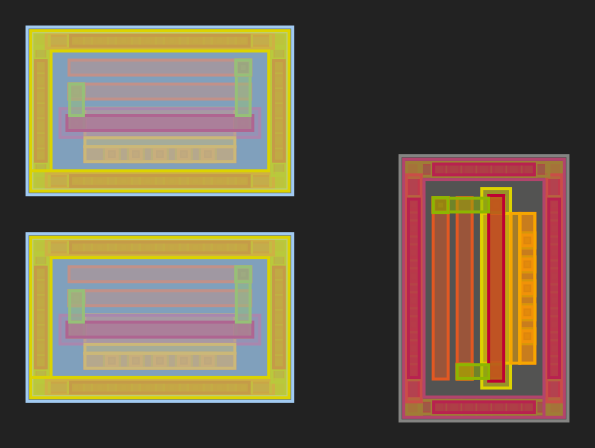

In [ ]:
# =========================================================================
# 9. COLOCACIÓN Y FLOORPLANNING 
# =========================================================================
from glayout.util.comp_utils import (
    align_comp_to_port,
    evaluate_bbox,
    prec_center,
    prec_ref_center,
)
M0_ref = top_comp << M0
M1_ref = top_comp << M1
M2_ref = top_comp << M2

M0_bbox = evaluate_bbox(M0)
M1_bbox = evaluate_bbox(M1)
M2_bbox = evaluate_bbox(M2)

M0_ref.move((0, 0))
M1_ref.move((0, -(M0_bbox[1] / 2 + M1_bbox[1] / 2 + spacing +2)))

M2_ref.rotate(90)
M2_ref.move((M1_ref.xmax + M2_bbox[0]/2 +  1.5*spacing, -(M0_bbox[1] / 2 + M1_bbox[1] / 2 + 0.25*spacing)))

display_component(top_comp, "./", scale=3)

In [10]:
###################################################
# 10. Create a via stack from met2 to met3
###################################################
viam2m3 = via_stack(pdk, "met2", "met4", centered=True) #met2 is the bottom layer. met3 is the top layer.

i_SUM_via = top_comp << viam2m3
ifwd_via = top_comp << viam2m3


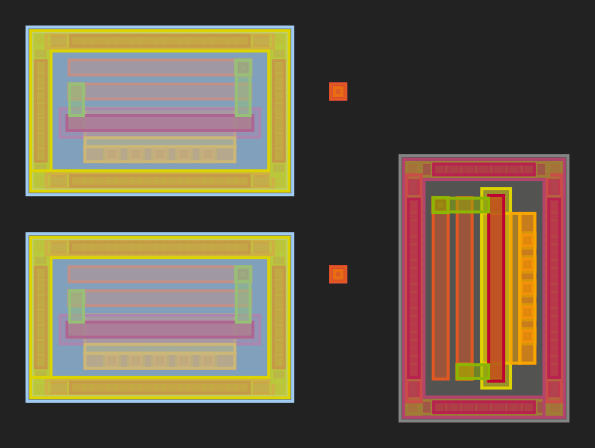

In [11]:
###################################################
# 11. Moving via stack from met2 to met3
###################################################

i_SUM_via.move(M0_ref.ports["multiplier_0_source_E"].center).movex(M1_bbox[1] / 3 + spacing - 0.25)
ifwd_via.move(M1_ref.ports["multiplier_0_drain_E"].center).movex(M1_bbox[1] / 3 + spacing - 0.25)

display_component(top_comp, "./", scale=3)

In [12]:
import gdsfactory as gf
from gdsfactory import Component
from gdsfactory.components import text_freetype, rectangle


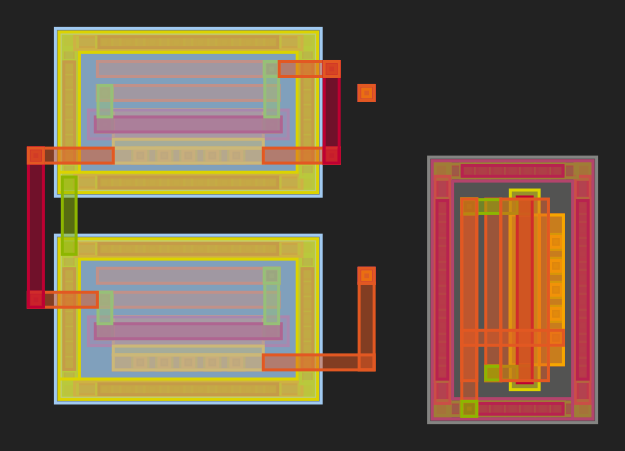

In [13]:

###################################################
# 12.b Internal Conections
###################################################
top_comp << straight_route( pdk, M0_ref.ports["tie_W_top_met_S"], M1_ref.ports["tie_W_top_met_N"])
top_comp << c_route(pdk, M1_ref.ports["source_W"], M0_ref.ports["gate_W"], extension=1.8)
top_comp << c_route(pdk, M0_ref.ports["gate_E"], M0_ref.ports["drain_E"], extension=1.5)
top_comp << L_route(pdk, M1_ref.ports["gate_E"], ifwd_via.ports["bottom_met_S"])
top_comp << straight_route(pdk, M2_ref.ports["source_S"], M2_ref.ports["gate_N"])
top_comp << straight_route(pdk, M2_ref.ports["gate_S"], M2_ref.ports["drain_N"])
top_comp << straight_route(pdk, M2_ref.ports["drain_E"], M2_ref.ports["tie_W_top_met_N"])

display_component(top_comp, "./", scale=3)

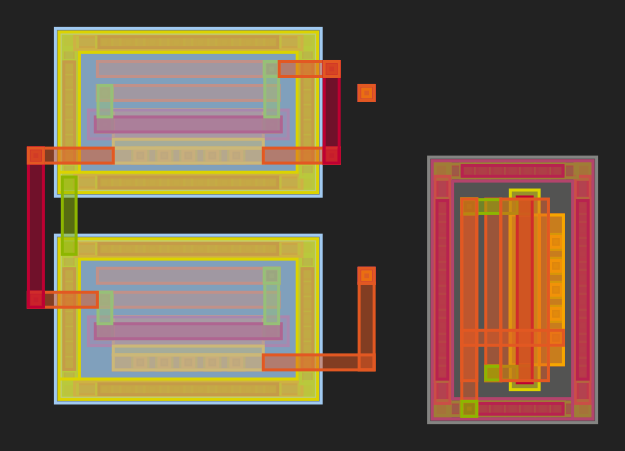

In [14]:
# top_comp.add_ports(M0_ref.get_ports_list(), prefix="M0_")
# top_comp.add_ports(M1_ref.get_ports_list(), prefix="M1_")

# top_comp.add_ports(i_SUM_via.get_ports_list(), prefix="i_SUM_")
# top_comp.add_ports(ifwd_via.get_ports_list(), prefix="ifwd_")
# top_comp.add_ports(M2_ref.get_ports_list(), prefix="M2_")
display_component(top_comp, "./", scale=3)


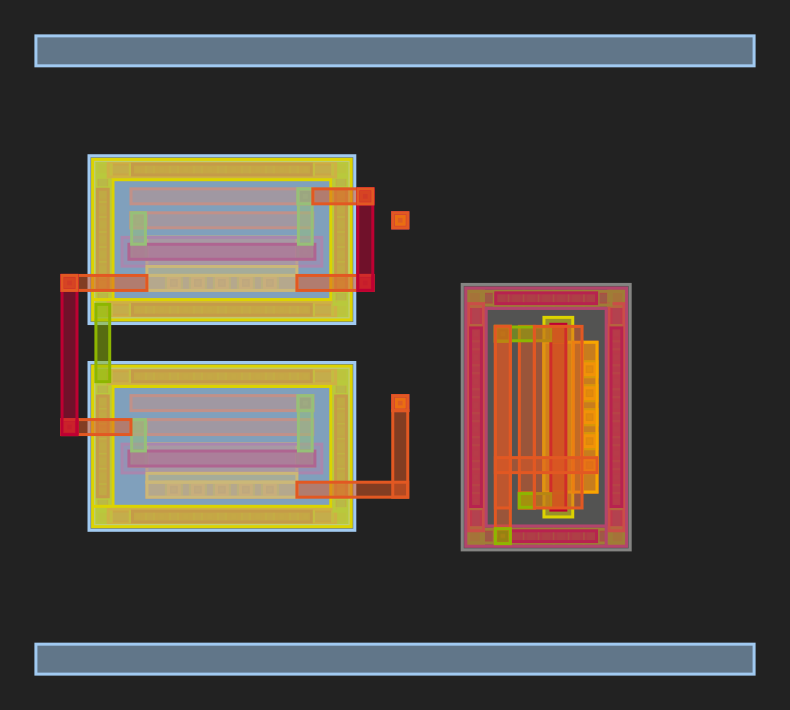

In [15]:
# =========================================================================
# 4. ADD AVDD POWER RAIL AND CONNECT SUPPLY NODES
# =========================================================================

# Calcular extensión horizontal para trazar el riel de alimentación
bbox = evaluate_bbox(top_comp)
top_y = top_comp.ymax + 3.0

# Trazar riel horizontal de metal2 para AVDD
avdd_rail = top_comp << gf.components.rectangle(
    size=(bbox[0] + 5, 1.0), 
    layer=pdk.get_layer("metal5")
)
avdd_rail.move(((M1_bbox[1] / 2) - 9, top_y))

# Trazar riel horizontal de metal2 para AVSS
avss_rail = top_comp << gf.components.rectangle(
    size=(bbox[0] + 5, 1.0), 
    layer=pdk.get_layer("metal5")
)
avss_rail.move(((M1_bbox[1] / 2) - 9, -2.5*top_y))

display_component(top_comp, "./", scale=3)



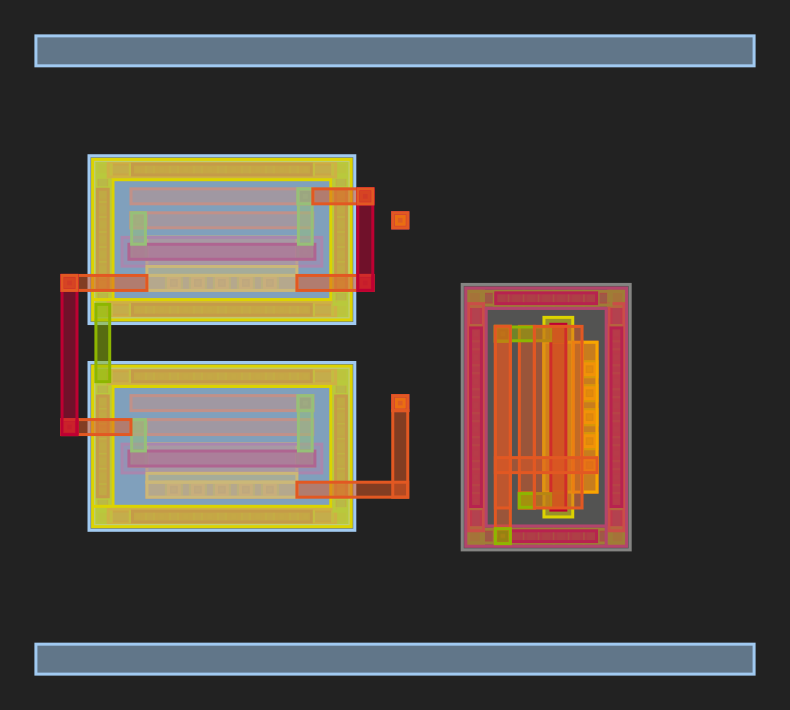

In [16]:
display_component(top_comp, "./", scale=3)

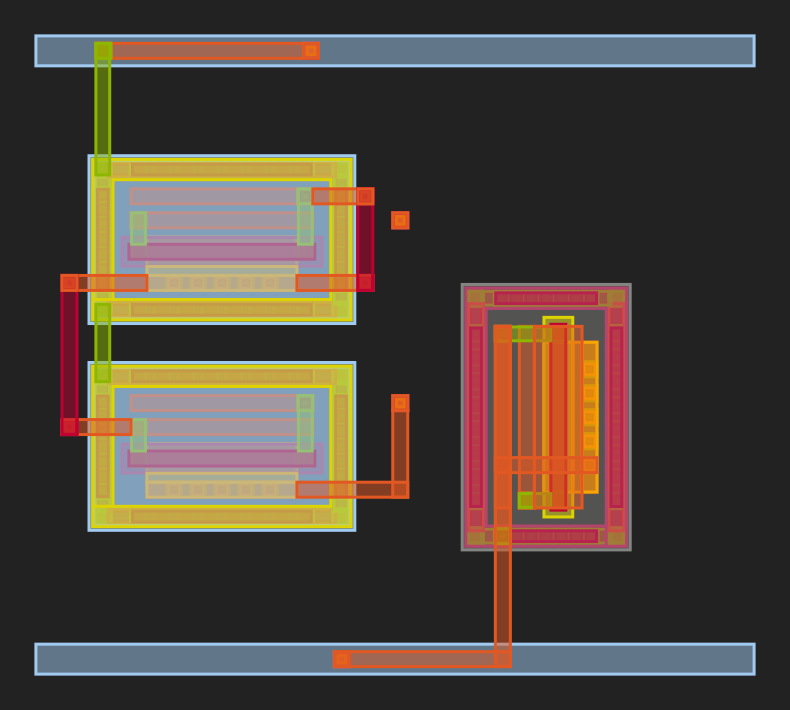

In [17]:
bbox1 = evaluate_bbox(top_comp)
viam2m5 = via_stack(pdk, "met2", "met5", centered=True) #met2 is the bottom layer. met3 is the top layer

avdd_M5_PIN = top_comp << viam2m5
avdd_M5_PIN.move((bbox[0] / 2 - 6.5, top_y + 0.5))

top_comp << L_route(pdk, M0_ref.ports["tie_W_top_met_N"], avdd_M5_PIN.ports["bottom_met_W"])

avss_M5_PIN = top_comp << viam2m5
avss_M5_PIN.move((4,-2.5*top_y + 0.5))

top_comp << L_route(pdk,avss_M5_PIN.ports["bottom_met_W"], M2_ref.ports["drain_E"])


display_component(top_comp, "./", scale=3)


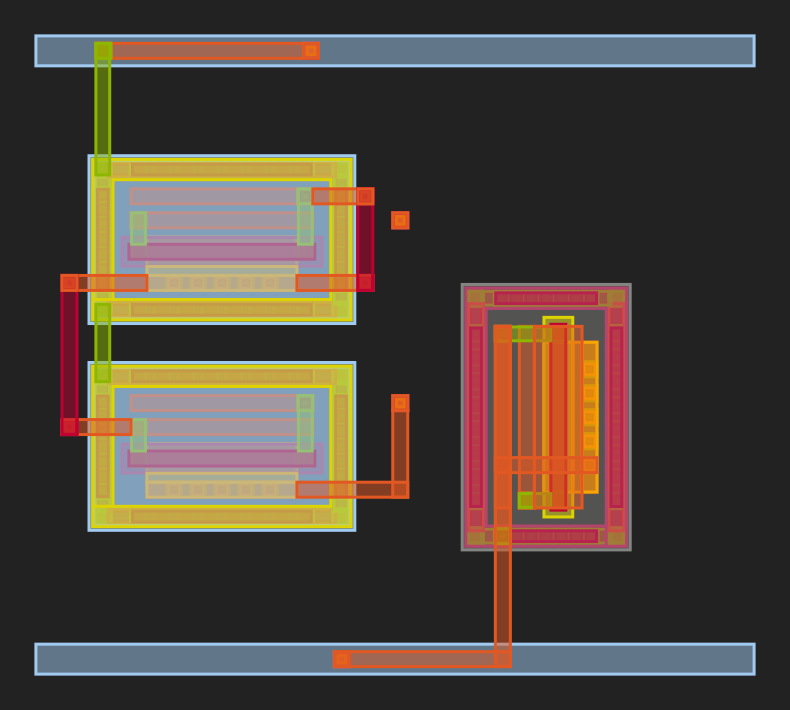

In [18]:
#----------- Adding snippet code to move all the placed components to the proper position, 
#----------- in order to set origin into 0,0
# Place this snippet after all your material polygones are placed, and before your ports are placed
bbox_all = top_comp.bbox[0]
for ref in top_comp.references:
    ref.movex(-1*bbox_all[0]).movey(-1*bbox_all[1])
display_component(top_comp, "./", scale=3)

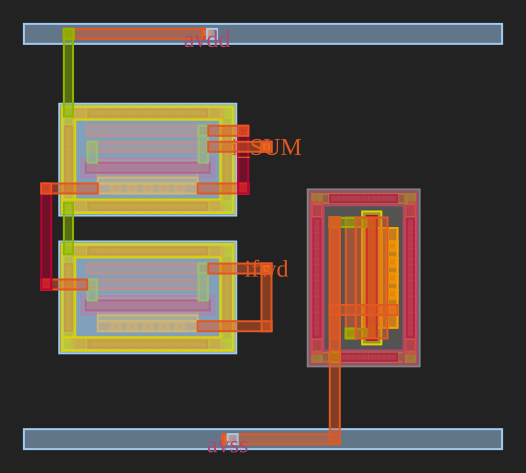

In [19]:

# =========================================================================
# 5. ADD PORTS AND PHYSICAL PIN LABELS (done BEFORE routing)
# =========================================================================

psize = (0.5, 0.5)

# i_SUM
box_isum = evaluate_bbox(i_SUM_via)
center_S_i_SUM = i_SUM_via.ports["bottom_met_S"].center

# i_SUM_port = top_comp << gf.components.rectangle(size=psize, layer=pdk.get_layer("metal4"))
# i_SUM_port.move(i_SUM_via.ports["bottom_met_S"].center)
top_comp.add_port(
    "i_SUM",
    center= i_SUM_via.center, # Move the port up by half the height of the bounding box plus an offset
    width=1.0,
    orientation=180,
    layer=pdk.get_layer("metal4"),
    port_type="electrical"
)
top_comp.add_label(
    text="i_SUM",
    position=i_SUM_via.center,
    layer=pdk.get_glayer("met4_label"),
    magnification=1
)

# ifwd
box_ifwd = evaluate_bbox(ifwd_via)
center_S_ifwd = ifwd_via.ports["bottom_met_S"].center

top_comp.add_port(
    "ifwd",
    center=ifwd_via.center,
    width=1.0,
    orientation=180,
    layer=pdk.get_layer("metal4"),
    port_type="electrical"
)
top_comp.add_label(
    text="ifwd",
    position=ifwd_via.center,
    layer=pdk.get_glayer("met4_label"),
    magnification=1
)

###################################################
# 12.a Pin Conections
###################################################
top_comp << straight_route(pdk, M0_ref.ports["multiplier_0_source_E"], i_SUM_via.ports["bottom_met_W"])
top_comp << straight_route(pdk, M1_ref.ports["multiplier_0_drain_E"], ifwd_via.ports["bottom_met_W"])


# avdd (bulk tie, via avdd1)

avdd_port = top_comp << gf.components.rectangle(size=psize, layer=pdk.get_layer("metal5"))
avdd_port.move(avdd_M5_PIN.ports["top_met_S"].center)



top_comp.add_port(
    "avdd",
    center=avdd_M5_PIN.ports["top_met_S"].center,
    width=1.0,
    orientation=180,
    layer=pdk.get_layer("metal5"),
    port_type="electrical"
)
top_comp.add_label(
    text="avdd",
    position=avdd_M5_PIN.ports["top_met_S"].center,
    layer=pdk.get_glayer("met5_label"),
    magnification=1
)
################################################################################################

avss_port = top_comp << gf.components.rectangle(size=psize, layer=pdk.get_layer("metal5"))
avss_port.move(avss_M5_PIN.ports["top_met_S"].center)

top_comp.add_port(
    "avss",
    center=avss_M5_PIN.ports["top_met_S"].center,
    width=1.0,
    orientation=180,
    layer=pdk.get_layer("metal5"),
    port_type="electrical"
)
top_comp.add_label(
    text="avss",
    position=avss_M5_PIN.ports["top_met_S"].center,
    layer=pdk.get_glayer("met5_label"),
    magnification=1
)

display_component(top_comp, "./", scale=2)


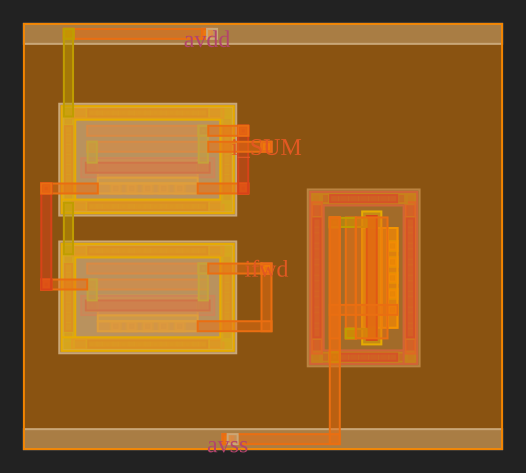

In [20]:
bbox1 = evaluate_bbox(top_comp)
boundary = top_comp << gf.components.rectangle(
    size=(bbox1[0], bbox1[1]), 
    layer=(0,0)
)
boundary.move((top_comp.xmin, top_comp.ymin))
display_component(top_comp, "./", scale=2)

In [21]:
evaluate_bbox(top_comp)

(23.94, 21.3)

In [22]:
evaluate_bbox(top_comp)[0]*evaluate_bbox(top_comp)[1]


509.922

In [23]:
top_comp.name="Current_limit"
drc_result = gf180.drc_magic(top_comp, top_comp.name)
print("Making sure your environment varriables are still correctly set")
print(" I am using PDK in: ",os.environ['PDK_ROOT'],"\n PDK name: ",os.environ['PDK'],"\n The PDK files are at: ",os.environ['PDKPATH'])

2026-09-02 18:49:58.574 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpyfwkpkor/Current_limit.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpyfwkpkor/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0

In [24]:
top_comp.unlock()

In [25]:
import os
from pathlib import Path
import tempfile
magicrc_file = Path(os.environ['PDKPATH']) / "libs.tech" / "magic" / f"{os.environ['PDK']}.magicrc"
design_name = top_comp.name
path_to_dir = "/foss/designs/libs/snn_analog/Current_limit/"
pex_path = path_to_dir + f"{design_name}.spice"
gds_path = path_to_dir + f"{design_name}.gds"
lef_path = path_to_dir + f"{design_name}.lef"

top_comp.write_gds(str(gds_path))

magic_script_content = f"""
drc off            
gds flatglob *\*
gds read {gds_path}

flatten {design_name}
load {design_name}
select top cell
extract do local
extract all
ext2sim labels on
ext2sim
extresist tolerance 10
extresist
ext2spice lvs
ext2spice cthresh 0
ext2spice extresist on
ext2spice -o {str(pex_path)}
port avdd use power
port avss use ground
lef write {lef_path}
exit
"""


with tempfile.NamedTemporaryFile(mode='w', delete=False) as magic_script_file:
    magic_script_file.write(magic_script_content)
    magic_script_path = magic_script_file.name
    
magic_cmd = f"bash -c 'magic -rcfile {magicrc_file} -noconsole -dnull < {magic_script_path}'",
magic_subproc = subprocess.run(
    magic_cmd, 
    shell=True,
    check=True,
    capture_output=True
)

magic_subproc_code = magic_subproc.returncode
magic_subproc_out = magic_subproc.stdout.decode('utf-8')
print(magic_subproc_out)


2026-09-02 18:49:58.942 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/Current_limit/Current_limit.gds'



Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using GDS-II Release 6.0
Library name: library
Reading "Current_limit".
Reading "M0".
Saving c

In [26]:
gf180.lvs_netgen(
    layout=top_comp,
    design_name = top_comp.name,
    pdk_root = Path(os.environ['PDKPATH']),
    lvs_setup_tcl_file = Path(os.environ['PDKPATH']) / "libs.tech" / "netgen" / f"{os.environ['PDK']}_setup.tcl",
    lvs_schematic_ref_file = Path(str(path_to_dir + "Current_limit.spice")),
    netlist = Path(str(path_to_dir + "Current_limitSCH.spice")),
    output_file_path =  Path(str(path_to_dir))
)



2026-09-02 18:49:59.193 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpxsnlo8dq/Current_limit.gds'


using user specified pdk_root, will search for required files in the specified directory

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using

{'magic_subproc_code': 0,
 'netgen_subproc_code': 0,
 'result_str': 'LVS run succeeded\nErrors found in LVS report: /tmp/tmpxsnlo8dq/Current_limit_lvs.rpt'}

In [27]:
from pathlib import Path
import os
import subprocess

pdk_name = os.environ.get("PDK", "gf180mcuD")
pdk_root = Path(os.environ.get("PDK_ROOT", ""))
pdk_path_env = Path(os.environ.get("PDKPATH", ""))

# Resolve the correct magicrc path even if PDKPATH is stale or duplicated.
candidate_pdkpaths = [
    pdk_path_env,
    pdk_root / pdk_name,
    pdk_root,
]
magicrc_file = None
for candidate in candidate_pdkpaths:
    if not str(candidate):
        continue
    rc = candidate / "libs.tech" / "magic" / f"{pdk_name}.magicrc"
    if rc.exists():
        magicrc_file = rc
        break

if magicrc_file is None:
    raise FileNotFoundError(
        "No se encontro el magicrc. Revisar PDK_ROOT/PDK/PDKPATH. "
        f"Busque en: {[str(c) for c in candidate_pdkpaths if str(c)]}"
    )

# --- Cambio clave: usar path_to_dir en vez de Path.cwd()/"exports" ---
path_to_dir = "/foss/designs/libs/snn_analog/Current_limit/"
output_dir = Path(path_to_dir)
output_dir.mkdir(parents=True, exist_ok=True)

design_name = top_comp.name
gds_path = output_dir / f"{design_name}.gds"
lef_path = output_dir / f"{design_name}.lef"

top_comp.write_gds(str(gds_path))

magic_script = f"""
drc off
gds flatglob *\\$\\$*
gds read {gds_path}
load {design_name}
port avdd use power
port avss use ground
lef write {lef_path}
quit -noprompt
"""

result = subprocess.run(
    ["magic", "-rcfile", str(magicrc_file), "-noconsole", "-dnull"],
    input=magic_script,
    text=True,
    capture_output=True,
    check=True,
)

print(f"CWD kernel: {Path.cwd()}")
print(f"LEF generado: {lef_path}")
print(f"LEF existe: {lef_path.exists()}")
if lef_path.exists():
    print("\nCabecera LEF:")
    with open(lef_path, "r", encoding="utf-8", errors="ignore") as f:
        for _ in range(15):
            line = f.readline()
            if not line:
                break
            print(line.rstrip())
else:
    print("\n--- STDOUT COMPLETO DE MAGIC (para depurar) ---")
    print(result.stdout)
    print("\n--- STDERR COMPLETO DE MAGIC ---")
    print(result.stderr)

2026-09-02 18:49:59.478 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/Current_limit/Current_limit.gds'


CWD kernel: /foss/designs
LEF generado: /foss/designs/libs/snn_analog/Current_limit/Current_limit.lef
LEF existe: True

Cabecera LEF:
VERSION 5.7 ;
  NOWIREEXTENSIONATPIN ON ;
  DIVIDERCHAR "/" ;
  BUSBITCHARS "[]" ;
MACRO Current_limit
  CLASS BLOCK ;
  FOREIGN Current_limit ;
  ORIGIN 0.000 0.000 ;
  SIZE 23.940 BY 21.300 ;
  PIN i_SUM
    ANTENNADIFFAREA 0.300000 ;
    PORT
      LAYER Metal1 ;
        RECT 3.170 14.895 3.670 15.395 ;
        RECT 3.190 14.345 3.650 14.895 ;


In [28]:
import glob
extensions = [
            "els"
            "*.gds",
            "*.ext",
            "*.res.ext",
            "*.lvs.rpt",
            "*_lvs.rpt",
            "*.nodes",
            "*.sim",
            "*.pex.spice",
            "*_pex.spice"
            ]
files_to_delete = []
for ext in extensions:
    files_to_delete.extend(glob.glob(ext))
    
# Delete the files
for file_path in files_to_delete:
    try:
        os.remove(file_path)
        print(f"Deleted: {file_path}")
    except OSError as e:
        print(f"Error deleting {file_path}: {e}")

Deleted: Current_limit.nodes
Deleted: Current_limit.sim
